In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

In [ ]:
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state = None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state

        #Wiener Process by default
        self.bxt = lambda x: 0
        self.sigmaxt = lambda x: 1

    def sampler_init_state(self):
        return np.zeros(self.Nx)

    def EulerSolution(self):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            x_data[0] = self.sampler_init_state()
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            dwt = np.random.normal(0, 1, size = self.Nx) * np.sqrt(dt)
            x_data[i] = x_data[i - 1] + self.bxt(x_data[i - 1]) * dt + self.sigmaxt(x_data[i - 1]) * dwt
        return t_data, x_data
    

# Примеры

Exercise 1. Use the stochastic integral Ito, $N=1000$ to simulate and plot a path with $X_0 = 10$ of
*   the Ornstein-Uhlenbeck process, $\mathbb{\theta} = (-5.0, 0.0, 3.5)$;
*   the Cox-Ingersoll-Ross process, $\mathbb{\theta} = (2.00, 0.20, 0.15)$;
*   the Black-Scholes-Merton process, $\mathbb{\theta} = (1.0, 0.2)$.


Пример 1. Используя стохастический интеграл Ито, $N=1000$, смоделируйте и постройте траекторию с $X_0 = 10$ для:
* процесса Орнштейна-Уленбека, $\mathbb{\theta} = (-5.0, 0.0, 3.5)$;
* процесса Кокса-Ингерсолла-Росса, $\mathbb{\theta} = (2.00, 0.20, 0.15)$;
* процесса Блэка-Шоулза-Мертона, $\mathbb{\theta} = (1.0, 0.2)$.

In [3]:
class OrnsteinUhlenbeckProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return self.params[1] * np.ones(self.Nx)


class CoxIngersollRossProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2, theta3]
        self.bxt = lambda x: self.params[0] - self.params[1] * x
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)


class BlackScholesMertonProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state = None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta1, theta2]
        self.bxt = lambda x: self.params[0] * x
        self.sigmaxt = lambda x: self.params[1] * x

    def sampler_init_state(self):
        return np.ones(self.Nx)

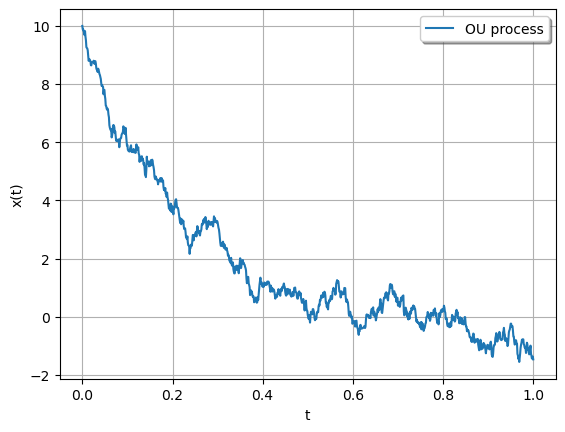

In [4]:
T = 1
Nx = 1
Nt = 1000

init_state = 10 * np.ones(Nx)

theta = 5
mu = 0
sigma = 3.5
params = [theta, mu, sigma]

OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)
t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'OU process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

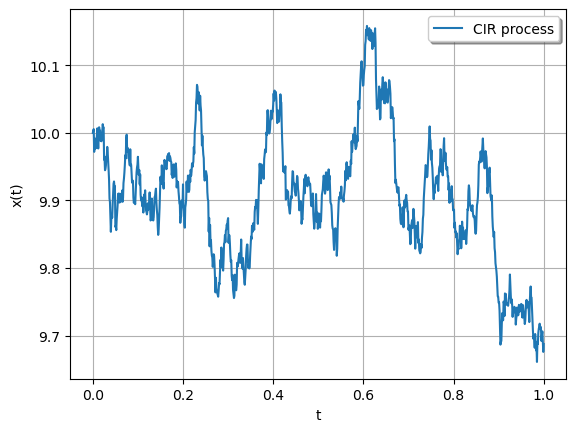

In [7]:
theta1 = 2
theta2 = 0.2
theta3 = 0.15
params = [theta1, theta2, theta3]

CIRProcess = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'CIR process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

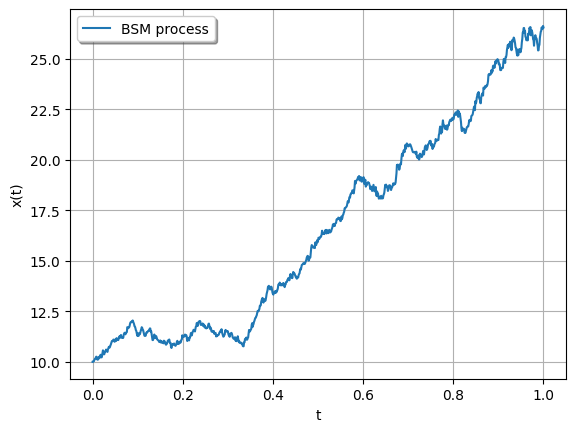

In [ ]:
theta1 = 1.0
theta2 = 0.2
params = [theta1, theta2]

BSMProcess = BlackScholesMertonProcess(params, T, Nx, Nt, init_state)
t_data, x_data = BSMProcess.EulerSolution()
plt.plot(t_data, x_data, label = 'BSM process')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Exercise 2. Compute a confidence interval of the CIR process from the previous task. Plot the paths and a confidence interval.

Пример 2. Вычислите доверительный интервал для процесса CIR из предыдущего примера. Постройте графики траекторий и доверительный интервал.

In [8]:
def zeta(sigma, theta, t, s):
    return sigma**2 / (4 * theta) * (1 - np.exp(-theta * (t - s)))

def CIRbounds(alpha_interval, params, t, s, xs):
    theta1, theta2, theta3 = params[0], params[1], params[2]
    theta = theta2
    beta = theta1 / theta2
    sigma = theta3

    k = 4  / sigma**2 * theta * beta
    lambd = 4 * theta / sigma**2  * np.exp(-theta * (t - s)) / (1 - np.exp(-theta * (t - s))) * xs
    ksi = norm.ppf(1 - alpha_interval / 2)

    b1 = zeta(sigma, theta, t, s) * (k + lambd - ksi * np.sqrt(2 * (k + 2 * lambd)))
    b2 = zeta(sigma, theta, t, s) * (k + lambd + ksi * np.sqrt(2 * (k + 2 * lambd)))
    return [b1, b2]


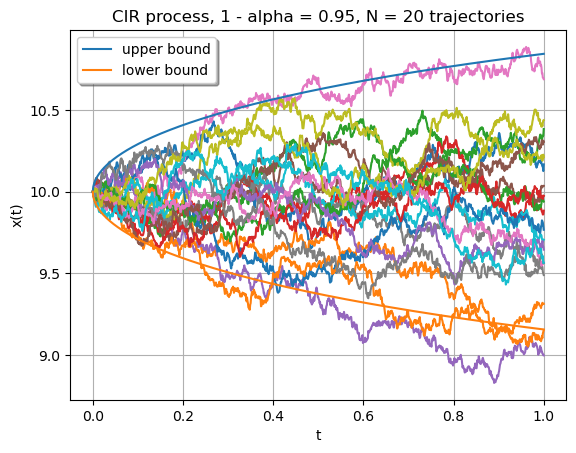

In [15]:
theta1 = 2
theta2 = 0.2
theta3 = 0.15
params = [theta1, theta2, theta3]

Nx = 20

x0 = 10
init_state = x0 * np.ones(Nx)
alpha_interval = 0.05

CIRProcess = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)
t_data, x_data = CIRProcess.EulerSolution()
for k in range(0, Nx):
    plt.plot(t_data, x_data[:,k])

low_bound_data = np.zeros_like(t_data)
up_bound_data = np.zeros_like(t_data)

for i in range(1, len(t_data)):
    bounds = CIRbounds(alpha_interval, params, t_data[i], 0, x0)
    low_bound_data[i] = bounds[0]
    up_bound_data[i] = bounds[1]
low_bound_data[0] = x0
up_bound_data[0] = x0
plt.plot(t_data, up_bound_data, label = f"upper bound")
plt.plot(t_data, low_bound_data, label = f"lower bound")

plt.title(f"CIR process, 1 - alpha = {1-alpha_interval}, N = {Nx} trajectories")
plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

Exercise 3. For the Ornstein-Uhlenbeck process
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t, \quad \theta = 1, \quad \mu = 1.2, \quad \sigma = 0.3
$$
generate three paths: $X_0 = 0.0, 2.0, \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$ and plot in graph.


Пример 3. Для процесса Орштейна-Улумбека
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t, \quad \theta = 1, \quad \mu = 1.2, \quad \sigma = 0.3
$$
сгенерируйте три траектории: $X_0 = 0.0, 2.0, \mathcal{N}\left(\mu, \frac{\sigma^2}{2\theta}\right)$ и постройте их на одном графике.


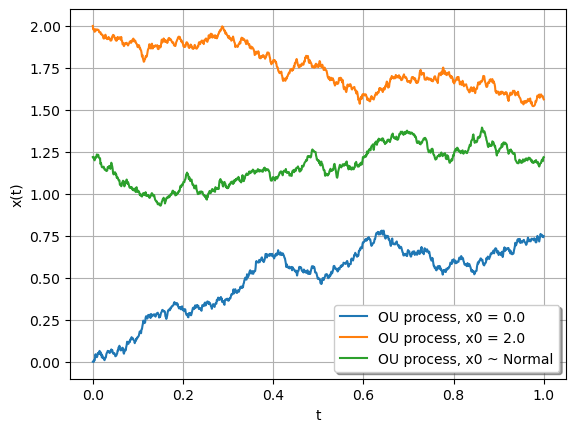

In [16]:
T = 1
Nx = 1
Nt = 1000

theta = 1
mu = 1.2
sigma = 0.3
params = [theta, mu, sigma]

x0 = 0.0
init_state = x0 * np.ones(Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 = {x0}')

x0 = 2.0
init_state = x0 * np.ones(Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 = {x0}')


init_state = np.random.normal(mu, sigma**2/(2 * theta), size = Nx)
OUProcess = OrnsteinUhlenbeckProcess(params, T, Nx, Nt, init_state)

t_data, x_data = OUProcess.EulerSolution()
plt.plot(t_data, x_data, label = f'OU process, x0 ~ Normal')

plt.legend(loc = 'best', fancybox = True, shadow = True)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# Exercises

Exercise 1. Define a path with the stationary distribution from the graph and prove mathematically.

In [20]:
import numpy as np

P = np.array([[0, 0.5, 0.5],
              [0.5, 0, 0.5],
              [0.5, 0.5, 0]])

# cтационарное распределение 
vals, vecs = np.linalg.eig(P.T)
pi = vecs[:, np.isclose(vals, 1)].real.flatten()
pi /= pi.sum()  # Нормировка: сумма вероятностей = 1

#assert np.allclose(pi @ P, pi), "Условие стационарности нарушено"

print(f"Стационарное распределение: {pi}")

Стационарное распределение: [0.33333333 0.33333333 0.33333333]


Exercise 2.  Design a process that stays in the interval $[0, 1]$ and mean-reverts around $1/2$, generate paths for different $\theta$ and plot their in graph. Prove your solution.


Hint
$$
\mu(x) = \theta (1/2 - x), \quad \sigma(x) = \sigma \cdot x (1-x).
$$

That is
$$
dx = \theta (1/2 - x )dt + \sigma \cdot x (1-x) dW.
$$
Note: diffusion goes to zero at boundaries $\sigma(0) = \sigma(1) = 0$ and
mean-reverts  $⇒$ always stay in $[0, 1]$.

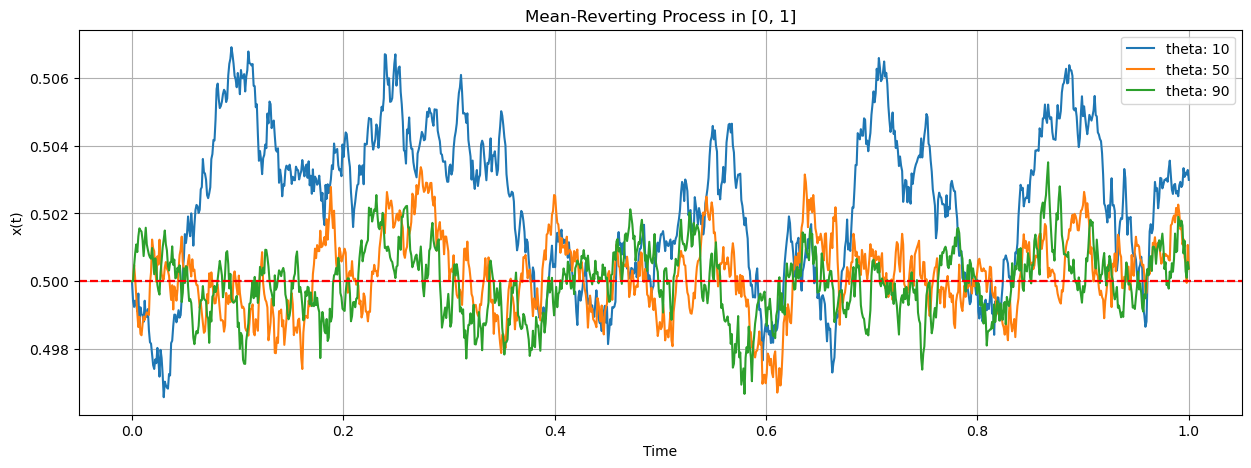

In [30]:
def DesingProcess(theta=0, n=10):
    # Parameters
    T = 1.0        # Total time
    Nt = 1000      # Number of time steps
    # theta = 5.0  # Mean reversion speed
    sigma = 0.05   # Volatility

    # Time discretization
    dt = T / Nt
    t = np.linspace(0, T, Nt)

    # Initial state
    x0 = 0.5  # Starting at the mean
    x_data = np.zeros(Nt)
    x_data[0] = x0


    plt.figure(figsize=(15,5))
    for theta in np.arange(10, 100, 40):
        # Simulating the process
        for i in range(1, Nt):
            x_prev = x_data[i - 1]
            drift = theta * (0.5 - x_prev) * dt
            diffusion = sigma * x_prev * (1 - x_prev) * np.sqrt(dt) * np.random.normal()
            x_data[i] = x_prev + drift + diffusion

        # Plotting the result
        plt.plot(t, x_data, label=f'theta: {theta}')
        plt.axhline(y=0.5, color='r', linestyle='--')
        plt.xlabel('Time')
        plt.ylabel('x(t)')
        plt.title('Mean-Reverting Process in [0, 1]')
        plt.legend()
        plt.grid(True)
    plt.show()

DesingProcess()

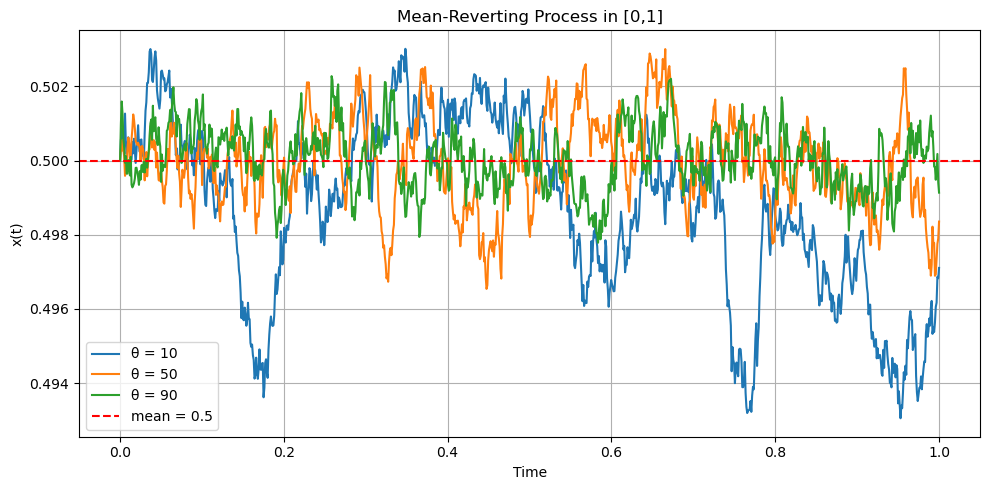

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_path(theta, sigma=0.05, T=1.0, Nt=1000, x0=0.5):
    """Euler-Maruyama: dx = θ(0.5-x)dt + σ·x(1-x)dW"""
    dt, t = T/Nt, np.linspace(0, T, Nt)
    x = np.empty(Nt); x[0] = np.clip(x0, 0, 1)
    for i in range(1, Nt):
        drift = theta * (0.5 - x[i-1]) * dt
        diffusion = sigma * x[i-1] * (1 - x[i-1]) * np.sqrt(dt) * np.random.normal()
        x[i] = np.clip(x[i-1] + drift + diffusion, 0, 1)  # boundary safety
    return t, x

# Plot paths for different θ
plt.figure(figsize=(10, 5))
for theta in [10, 50, 90]:
    t, x = simulate_path(theta)
    plt.plot(t, x, label=f'θ = {theta}')
plt.axhline(0.5, color='red', linestyle='--', label='mean = 0.5')
plt.xlabel('Time'); plt.ylabel('x(t)'); plt.title('Mean-Reverting Process in [0,1]')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Exercise 3. Sove Exercise 2 for common case: interval $[a, b]$ and mean-reverts around  $c$, where $c \sim U(a,b)$.

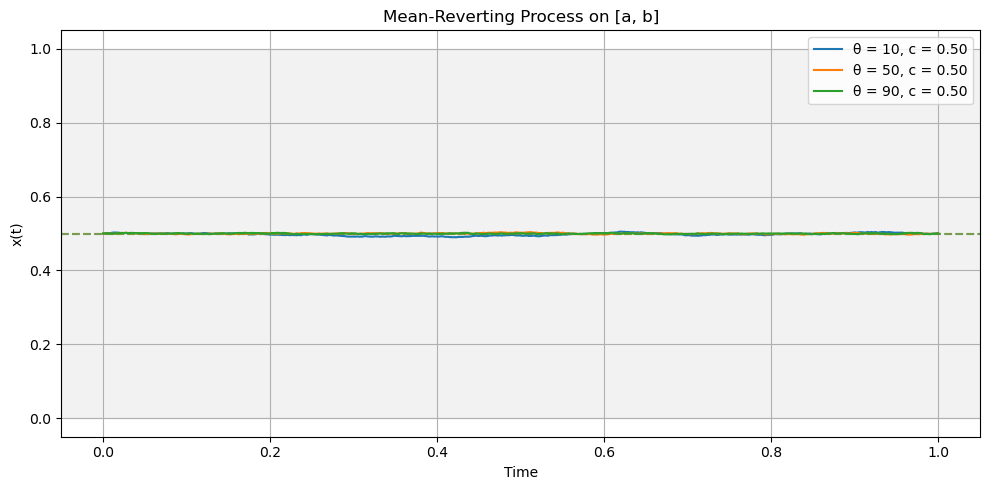

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_path_general(theta, a=0, b=1, c=None, sigma=0.05, T=1.0, Nt=1000, seed=None):
    """Euler-Maruyama: dx = θ(c-x)dt + σ·(x-a)(b-x)dW"""
    if c is None: c = (a+b)/2  # c ~ U(a,b)
    dt, t = T/Nt, np.linspace(0, T, Nt)
    x = np.empty(Nt); x[0] = c  # start at mean
    for i in range(1, Nt):
        drift = theta * (c - x[i-1]) * dt
        diffusion = sigma * (x[i-1]-a) * (b-x[i-1]) * np.sqrt(dt) * np.random.normal()
        x[i] = np.clip(x[i-1] + drift + diffusion, a, b)
    return t, x, c

# Plot paths for different θ with random c
plt.figure(figsize=(10, 5))
for theta in [10, 50, 90]:
    t, x, c = simulate_path_general(theta, a=0, b=1)
    plt.plot(t, x, label=f'θ = {theta}, c = {c:.2f}')
    plt.axhline(c, color=plt.gca().lines[-1].get_color(), linestyle='--', alpha=0.5)
plt.axhspan(0, 1, alpha=0.1, color='gray')
plt.xlabel('Time'); plt.ylabel('x(t)'); plt.title('Mean-Reverting Process on [a, b]')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

Exercise 4. Using the class template from Task 1, create classes and plot graphs for the following processes:

1.   Modified CIR model;
2.   Chan-Karolyi-Longstaff-Sanders family of models;
1.   Nonlinear mean reversion Ait-Sahalia model;
2.   Jacobi diffusion process;
1.   Ahn and Gao (inverse of Feller’s square root) model;
2.   Radial Ornstein-Uhlenbeck process.

Provide examples for illustration the results on graphs.





In [34]:
class ModifiedCIRProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [36]:
class CKLSProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma, alpha]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * x ** self.params[3]

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [37]:
class AitSahaliaProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x ** 2)
        self.sigmaxt = lambda x: self.params[2]

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1] ** 0.5)

In [38]:
class JacobiProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * (1 - x) * (1 + x)

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [39]:
class AhnGaoProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, mu, sigma]
        self.bxt = lambda x: self.params[0] * (self.params[1] - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))

    def sampler_init_state(self):
        return np.full(self.Nx, self.params[1])

In [40]:
class RadialOUProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [theta, sigma]
        self.bxt = lambda x: -self.params[0] * x
        self.sigmaxt = lambda x: self.params[1]

    def sampler_init_state(self):
        return np.zeros(self.Nx)  # Starting at the origin

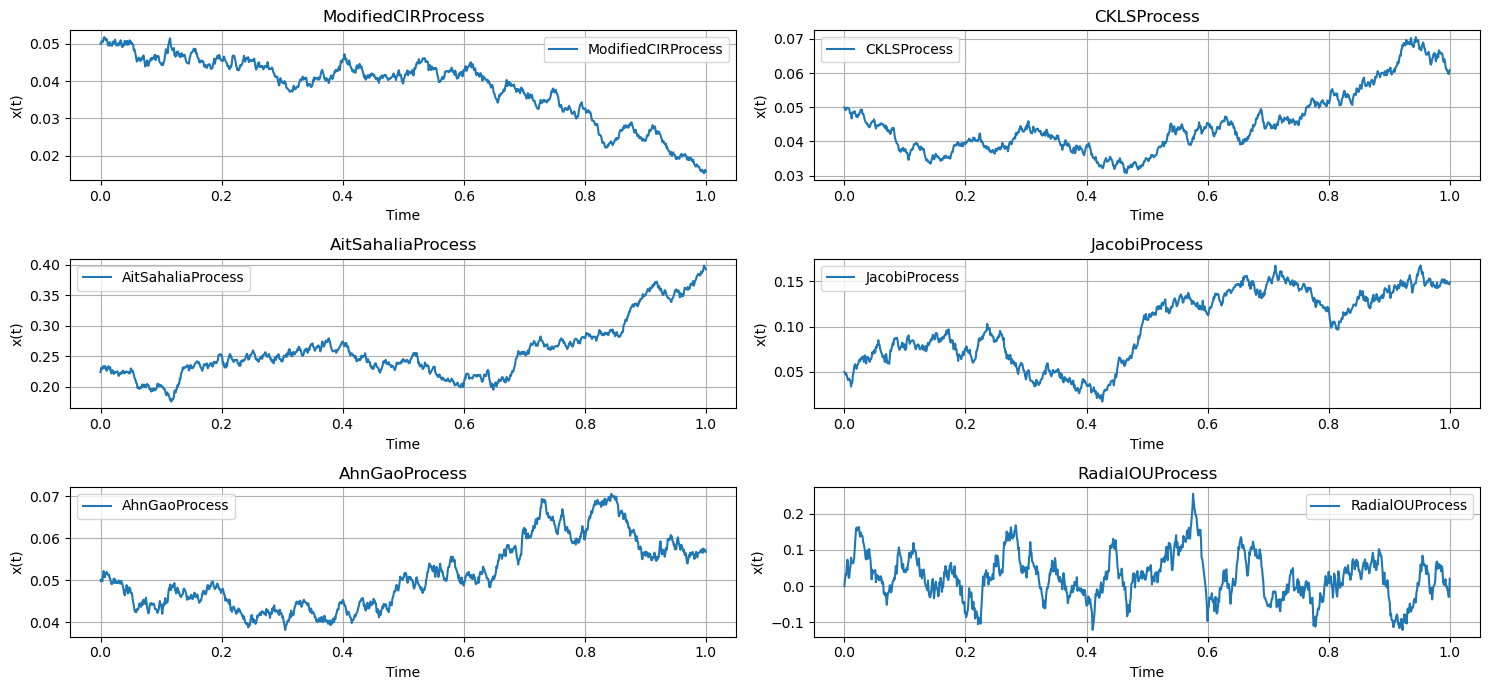

In [43]:
# Common parameters for the models
T = 1.0
Nx = 1
Nt = 1000

# Parameters for each model
params_cir = [0.1, 0.05, 0.1]  # Modified CIR
params_ckls = [0.1, 0.05, 0.1, 0.5]  # CKLS
params_ait = [0.1, 0.05, 0.1]  # Ait-Sahalia
params_jacobi = [0.1, 0.05, 0.1]  # Jacobi
params_ahn = [0.1, 0.05, 0.1]  # Ahn and Gao
params_radial_ou = [15, 0.5]  # Radial OU

# Create instances of each process
processes = [
    ModifiedCIRProcess(params_cir, T, Nx, Nt),
    CKLSProcess(params_ckls, T, Nx, Nt),
    AitSahaliaProcess(params_ait, T, Nx, Nt),
    JacobiProcess(params_jacobi, T, Nx, Nt),
    AhnGaoProcess(params_ahn, T, Nx, Nt),
    RadialOUProcess(params_radial_ou, T, Nx, Nt)
]

# Plotting each process
plt.figure(figsize=(15, 7))

for i, process in enumerate(processes):
    t_data, x_data = process.EulerSolution()
    plt.subplot(3, 2, i + 1)
    plt.plot(t_data, x_data, label=process.__class__.__name__)
    plt.title(process.__class__.__name__)
    plt.xlabel('Time')
    plt.ylabel('x(t)')
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

Exercise 5.

Let $$X(t)=e^{-\kappa t} X_0 + \theta (1-e^{-\kappa t}) + \sigma e^{-\kappa t} \int_0^t e^{\kappa s}\sqrt{X(t)}dW(s)$$ be extract solution for CIR model.


 Expand the functionality of the class CoxIngersollRossProcess(StochasticProcess) and compute the first and second moments of the extract solution $\mathbb{E}\{X^n(t)\}$ using the general formula [Jafari, 2017]
$$
\mathbb{E}\{X^n(t)\} = \sum_{j=0}^{[n/2]}A^{n-2j}(t)B^{2j}(t)
\left(\frac{1}{2\kappa}(e^{2\kappa t} - 1)\right)^{2j}, \quad \forall n \in \mathbb{N},
$$
where $A(t)=e^{-\kappa t X_0} + \theta(1-e^{-\kappa t})$,
$B(t)=\sigma e^{-\kappa t}$, $[n/2]$ denotes the greatest integer less than or equal to $\frac{n}{2}$ and $\kappa=1$, $\theta =0.45$, $\sigma=1$.



Jafari M.A. [The Moments for Solution of the Cox-Ingersoll-Ross Interest Rate Model](https://www.sciepub.com/portal/downloads?doi=10.12691/jfe-5-1-4&filename=jfe-5-1-4.pdf) / M.A. Jafari, S. Abbasian // Journal of Finance
and Economics. – 2017. – Vol. 5, № 1. – P. 34—37

In [44]:
import sympy as sp
from sympy import latex
from IPython.display import display, Math

# Определяем символы
X0, theta, kappa, sigma, t, n = sp.symbols('X0 theta kappa sigma t n')

# Функции A(t) и B(t)
def A(t):
    return sp.exp(-kappa * t) * X0 + theta * (1 - sp.exp(-kappa * t))

def B(t):
    return sigma * sp.exp(-kappa * t)

# Подставляем A(t) и B(t) без конкретных значений параметров
A_t = A(t)
B_t = B(t)

# Функция для вычисления n-го момента
def expected_moment(n):
    moment = 0
    max_j = n // 2  # [n/2]

    for j in range(max_j + 1):
        # Вычисляем A(t)^(n-2j) и B(t)^(2j)
        A_term = A_t**(n - 2 * j)
        B_term = B_t**(2 * j)

        # Часть с kappa
        kappa_part = (1 / (2 * kappa)) * (sp.exp(2 * kappa * t) - 1)
        kappa_term = kappa_part**(2 * j)

        # Суммируем
        moment += A_term * B_term * kappa_term

    return moment  # Возвращаем без подстановки значения t и вычисления

# Вычисляем первый и второй моменты
first_moment = expected_moment(1)
second_moment = expected_moment(2)

# Выводим общие аналитические результаты
display(Math(r'\mathbb{E}\{X(t)\} = ' + latex(first_moment)))
display(Math(r'\mathbb{E}\{X^2(t)\} = ' + latex(second_moment)))

# Конкретные значения параметров
kappa_val = 1
theta_val = 0.45
sigma_val = 1
t_val = 1  # Значение для t
X0_val = 0  # Значение для X0

# Подставляем значения параметров
first_moment_value = first_moment.subs({kappa: kappa_val, theta: theta_val, sigma: sigma_val, t: t_val, X0: X0_val}).evalf()
second_moment_value = second_moment.subs({kappa: kappa_val, theta: theta_val, sigma: sigma_val, t: t_val, X0: X0_val}).evalf()

# Выводим конкретные значения
print(f"E{{X(t)}} = {first_moment_value}")
print(f"E{{X^2(t)}} = {second_moment_value}")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280


In [45]:
class CoxIngersollRossProcess(StochasticProcess):
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)

        # params = [theta, kappa, sigma]
        self.bxt = lambda x: self.params[1] * (self.params[0] - x)  # kappa * (theta - x)
        self.sigmaxt = lambda x: self.params[2] * np.sqrt(np.maximum(x, 0))  # sigma * sqrt(X)

    def sampler_init_state(self):
        return self.params[0] / self.params[1] * np.ones(self.Nx)

    def expected_moment(self, n, t):
        # Определяем A(t) и B(t) с учетом параметров
        X0 = self.init_state if self.init_state is not None else self.params[0] / self.params[1]
        A_t = sp.exp(-self.params[1] * t) * X0 + self.params[0] * (1 - sp.exp(-self.params[1] * t))
        B_t = self.params[2] * sp.exp(-self.params[1] * t)

        moment = 0
        max_j = n // 2  # [n/2]

        for j in range(max_j + 1):
            A_term = A_t**(n - 2 * j)
            B_term = B_t**(2 * j)
            kappa_part = (1 / (2 * self.params[1])) * (sp.exp(2 * self.params[1] * t) - 1)
            kappa_term = kappa_part**(2 * j)
            moment += A_term * B_term * kappa_term

        return moment

# Пример использования класса
params = [0.45, 1, 1]  # [theta, kappa, sigma]
T = 1
Nx = 1
Nt = 100
init_state = 0

cir_process = CoxIngersollRossProcess(params, T, Nx, Nt, init_state)

# Вычисление первого и второго моментов в t=1
t_val = 1
first_moment = cir_process.expected_moment(1, t_val)
second_moment = cir_process.expected_moment(2, t_val)

# Выводим результаты
print(f"E{{X(t)}} = {first_moment.evalf()}")
print(f"E{{X^2(t)}} = {second_moment.evalf()}")

print(f"E{{X(t)}} = {first_moment_value}")
print(f"E{{X^2(t)}} = {second_moment_value}")

E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280
E{X(t)} = 0.284454251472851
E{X^2(t)} = 1.46201206672280


Exercise 5. Let assume  the CoxIngersoll-Ross model
$$
dX_t = (6 - 2X_t)dt + θ \sqrt{X_t}dW_t,
$$
where $θ = θ_1 = 1$ for $t < τ_0 = 0.6$ and $θ = θ_2$ for $t ≥ τ_0$ and $t ∈ (0, 1)$.

Simulate two paths $X_1$ and $X_2$ of the CIR process, one in $[0, τ_0]$ and the other in $[τ_0, 1]$, under the condition $X_2(τ_0) = X_1(τ_0)$, and we collate the two into one single trajectory.

Plot the path and add change point into graph (vetrical line).

Estimate $\hat{τ}$  and the two values of the volatility $\hat{θ}_1$ and $\hat{θ}_2$.

(Iuacus, 2008, p.208)

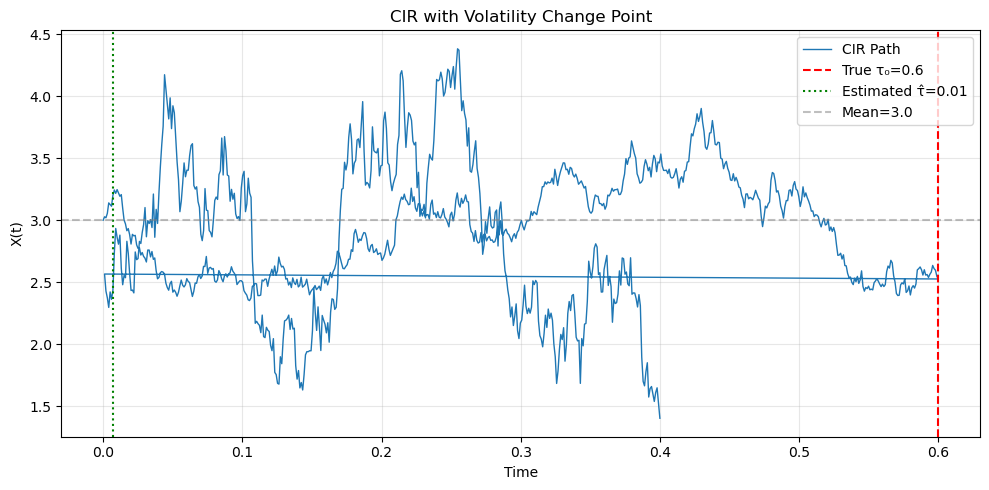

True:      θ₁=1.0, θ₂=3.0, τ₀=0.6
Estimated: θ̂₁=0.987, θ̂₂=2.971, τ̂=0.007


In [ ]:

def euler_maruyama(bxt, sigmaxt, T, Nt, x0, seed=None):
    """Внешняя симуляция через атрибуты класса"""
    if seed is not None: np.random.seed(seed)
    dt, t = T/Nt, np.linspace(0, T, Nt)
    x = np.zeros(Nt); x[0] = x0
    for i in range(1, Nt):
        x[i] = np.maximum(x[i-1] + bxt(x[i-1])*dt + sigmaxt(x[i-1])*np.sqrt(dt)*np.random.normal(), 0)
    return t, x

def estimate_sigma(x, dt, bxt):
    """Оценка σ через квадратичную вариацию"""
    dx = np.diff(x)
    drift = np.array([bxt(xi) for xi in x[:-1]]) * dt
    return np.sqrt(np.sum((dx - drift)**2) / (np.sum(np.maximum(x[:-1], 0)) * dt + 1e-10))

def estimate_change_point(t, x, bxt):
    """Поиск τ̂ по максимуму разницы волатильностей"""
    N, dt = len(x), t[1]-t[0]
    scores = [(k, np.abs(estimate_sigma(x[:k], dt, bxt) - estimate_sigma(x[k:], dt, bxt)))
              for k in range(int(0.3*N), int(0.9*N))]
    idx = max(scores, key=lambda v: v[1])[0]
    return t[idx], idx

# === Параметры: dX = (6−2X)dt + θ√X dW → κ=2, θ_long=3 ===
tau0, theta1, theta2 = 0.6, 1.0, 3.0
theta_long, kappa = 3.0, 2.0
T, Nt = 1.0, 1000
x0 = theta_long  # start at mean

# === Путь 1: [0, τ₀] с θ₁ ===
Nt1 = int(tau0 * Nt)
cir1 = CoxIngersollRossProcess([theta_long, kappa, theta1], T=tau0, Nx=1, Nt=Nt1)
t1, x1 = euler_maruyama(cir1.bxt, cir1.sigmaxt, tau0, Nt1, x0, seed=42)

# === Путь 2: [τ₀, 1] с θ₂, непрерывность в τ₀ ===
Nt2 = Nt - Nt1
cir2 = CoxIngersollRossProcess([theta_long, kappa, theta2], T=1-tau0, Nx=1, Nt=Nt2, init_state=np.array([x1[-1]]))
t2, x2 = euler_maruyama(cir2.bxt, cir2.sigmaxt, 1-tau0, Nt2, x1[-1], seed=43)

# === Объединение ===
t_full = np.concatenate([t1, t2[1:]])
x_full = np.concatenate([x1, x2[1:]])
dt = T / Nt

# === Оценка ===
tau_hat, tau_idx = estimate_change_point(t_full, x_full, cir1.bxt)
sigma1_hat = estimate_sigma(x_full[:tau_idx], dt, cir1.bxt)
sigma2_hat = estimate_sigma(x_full[tau_idx:], dt, cir1.bxt)

plt.figure(figsize=(10, 5))
plt.plot(t_full, x_full, label='CIR Path', linewidth=1)
plt.axvline(tau0, color='red', linestyle='--', label=f'True τ₀={tau0}')
plt.axvline(tau_hat, color='green', linestyle=':', label=f'Estimated τ̂={tau_hat:.2f}')
plt.axhline(theta_long, color='gray', linestyle='--', alpha=0.5, label=f'Mean={theta_long}')
plt.xlabel('Time'); plt.ylabel('X(t)'); plt.title('CIR with Volatility Change Point')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"True:      θ₁={theta1}, θ₂={theta2}, τ₀={tau0}")
print(f"Estimated: θ̂₁={sigma1_hat:.3f}, θ̂₂={sigma2_hat:.3f}, τ̂={tau_hat:.3f}")

Task 7. Suppose we have a standard (zero-mean) Ornstein-Uhlenbeck process defined by
$$
dX_t = -\theta X_t dt + \sigma dW_t, \quad X_0 = x_0,
$$
where $\sigma$ is interpreted as the volatility, and $\theta$ is the speed of reversion.

Define a half-life at time $s$ as the time $h$ such that $𝔼(x_h|x_s)=\frac{1}{2}x_s$. That is, how long until half the deviation from the mean is, in expectation, lost.

This is easy to compute because
\begin{align}
  \frac{1}{2}x_s & =  𝔼(x_h|x_s) \\
                 & = x_s\exp(-\theta h)
\end{align}
and we can cancel the $x_s$ terms to give
\begin{align}
  \frac{1}{2} = \exp(-\theta h)
\end{align}
which rearranges to
\begin{align}
  h = \frac{\ln(2)}{\theta}
\end{align}
The cancellation of $x_s$ means that a half-life does not depend on either $s$ or $x_s$ and so we are entitled to call it "the" half-life of the process.

As one can see, the half-life is a constant for an Ornstein-Uhlenbeck process.



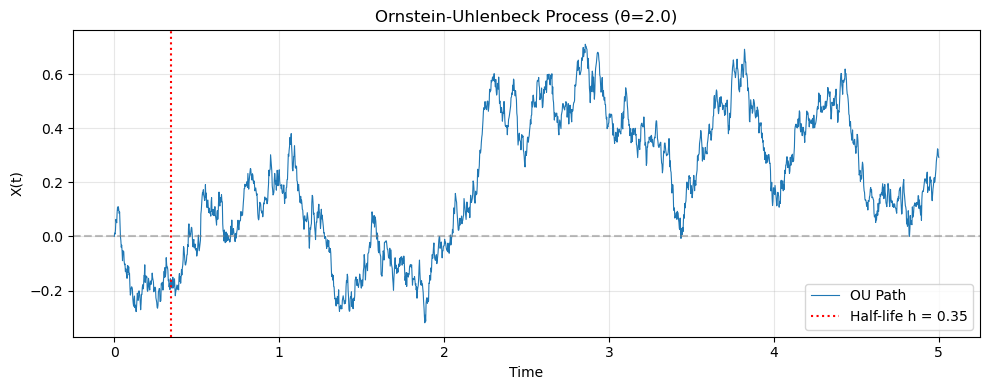

Theoretical half-life: h = ln(2)/θ = 0.3466
Empirical ratio E[Xₜ₊ₕ/Xₜ]: 0.6381 (target: 0.5)


In [ ]:

def simulate_ou(proc, seed=None):
    """Euler-Maruyama via proc.bxt, proc.sigmaxt"""
    if seed is not None: np.random.seed(seed)
    dt, x = proc.T/proc.Nt, np.zeros(proc.Nt)
    x[0] = proc.init_state[0] if proc.init_state is not None else proc.sampler_init_state()[0]
    for i in range(1, proc.Nt):
        x[i] = x[i-1] + proc.bxt(x[i-1])*dt + proc.sigmaxt(x[i-1])*np.sqrt(dt)*np.random.normal()
    return np.linspace(0, proc.T, proc.Nt), x

# Параметры: θ, μ=0, σ
theta, mu, sigma = 2.0, 0.0, 0.5
T, Nt = 5.0, 2000
h_theory = np.log(2) / theta  # теоретический half-life

# Симуляция
ou = OrnsteinUhlenbeckProcess([theta, mu, sigma], T=T, Nx=1, Nt=Nt)
t, x = simulate_ou(ou, seed=42)

# Эмпирическая проверка: E[X_{t+h} | X_t] ≈ 0.5·X_t
h_idx = int(h_theory / (T/Nt))
cond_mask = np.abs(x[:-h_idx]) > 0.5 
x_t = x[:-h_idx][cond_mask]
x_th = x[h_idx:][cond_mask]
ratio = np.mean(x_th / x_t) if len(x_t) > 0 else np.nan

# Plot
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='OU Path', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(h_theory, color='red', linestyle=':', label=f'Half-life h = {h_theory:.2f}')
plt.xlabel('Time'); plt.ylabel('X(t)'); plt.title(f'Ornstein-Uhlenbeck Process (θ={theta})')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Theoretical half-life: h = ln(2)/θ = {h_theory:.4f}")
print(f"Empirical ratio E[Xₜ₊ₕ/Xₜ]: {ratio:.4f} (target: 0.5)")

Пример. Смоделируйте составную траекторию с использованием процесса Cox-Ingersoll-Ross (CIR)
$$
dX_t = (6 - 2X_t)dt + \theta \sqrt{X_t}dW_t,  X(0)=1,
$$
где

$\theta = \theta_1 = 1$ для $t < \tau_0 = 0.6$ и

$\theta = \theta_2$ и $t \geq \tau_0$, $t \in (0, 1)$.

Постройте график смоделированной траектории, а также график статистики $|\hat{D}_k|$, укажите точку смены тенденции $k_0$ на графике траектории и сравните полученное значание с $\tau_0$.

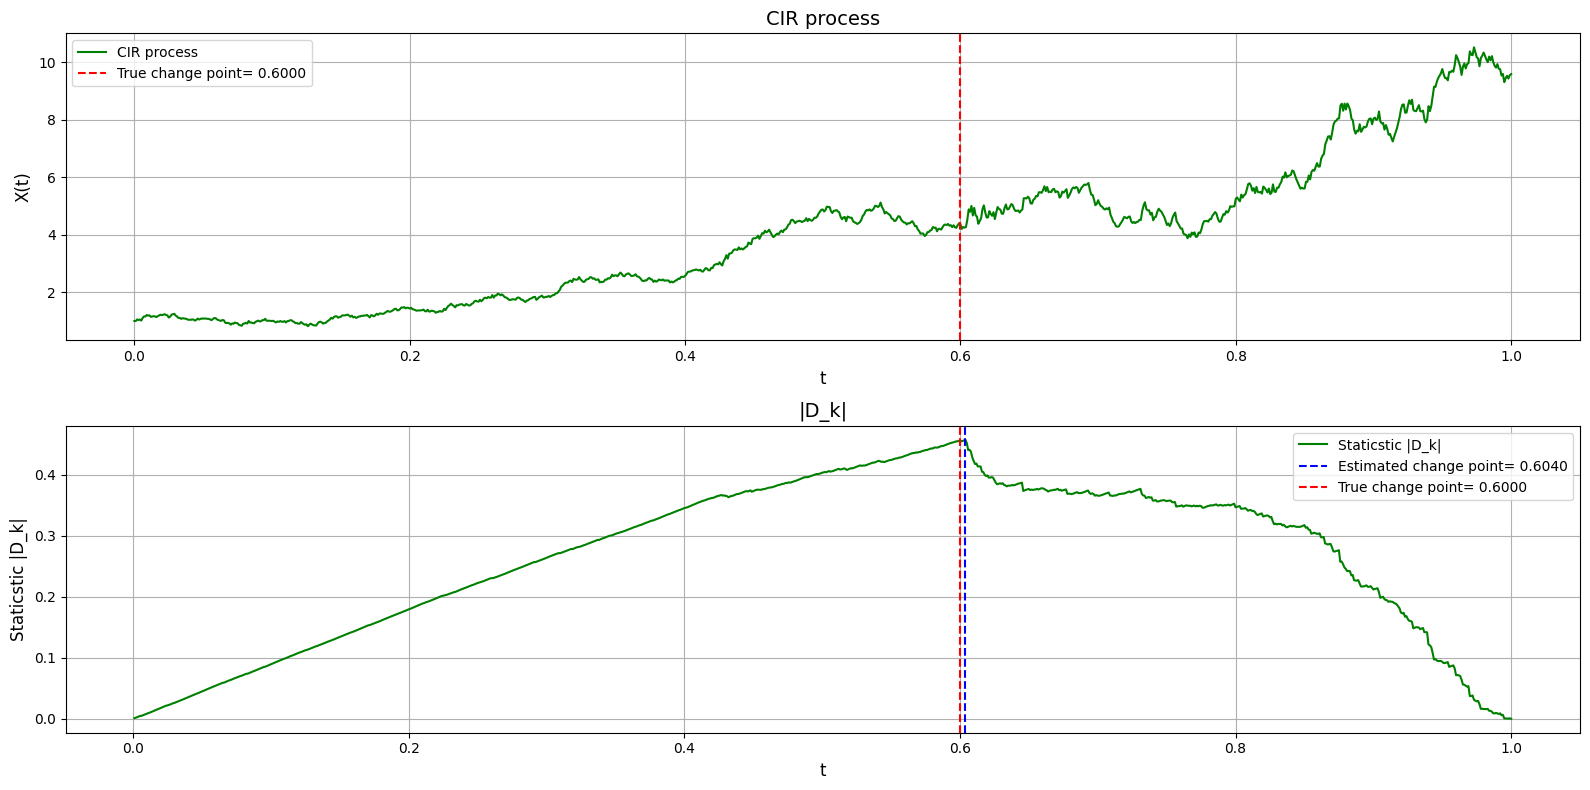

Истинный: t₀ = 0.6
Оценённый: y₀ = 0.6040


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class CIRProcessSimulation:
    def __init__(self, n=1000, T=1.0, tau0=0.6, theta1=1.0, theta2=2.0, X0=1.0):
        self.n = n
        self.T = T
        self.tau0 = tau0
        self.theta1 = theta1
        self.theta2 = theta2
        self.X0 = X0
        self.Δt = self.T / self.n
        self.t = np.linspace(0, self.T, self.n + 1)
        self.X = np.zeros(self.n + 1)
        self.X[0] = self.X0
        self.D_k = None

    def simulate(self):
        ΔW = np.sqrt(self.Δt) * np.random.randn(self.n)
        for i in range(self.n):
            theta = self.theta1 if self.t[i] < self.tau0 else self.theta2
            sqrt_Xi = np.sqrt(max(self.X[i], 0))
            self.X[i+1] = self.X[i] + (6 - 2 * self.X[i]) * self.Δt + theta * sqrt_Xi * ΔW[i]
            self.X[i+1] = max(self.X[i+1], 0)

    def estimate_change_point(self):
        Z = ((self.X[1:] - self.X[:-1]) - (6 - 2 * self.X[:-1]) * self.Δt) / np.sqrt(self.Δt)
        Z_squared = Z**2
        S_k = np.cumsum(Z_squared)
        S_n = S_k[-1]
        k_values = np.arange(1, self.n + 1)
        self.D_k = (S_k / S_n) - (k_values / self.n)
        k0 = np.argmax(np.abs(self.D_k))
        t0_estimate = self.t[k0 + 1]
        return t0_estimate

    def plot_results(self, t0_estimate):
        fig, axs = plt.subplots(2, 1, figsize=(16, 8))

        # Plot process
        axs[0].plot(self.t, self.X, color='green', label='CIR process')
        axs[0].axvline(x=self.tau0, color='red', linestyle='--', label=f'True change point= {tau0:.4f}')
        axs[0].set_xlabel('t', fontsize=12)
        axs[0].set_ylabel('X(t)', fontsize=12)
        axs[0].set_title('CIR process', fontsize=14)
        axs[0].legend()
        axs[0].grid(True)

        # Plot estimation
        axs[1].plot(self.t[1:], np.abs(self.D_k), color='green', label='Staticstic |D_k|')
        axs[1].axvline(x=t0_estimate, color='blue', linestyle='--', label=f'Estimated change point= {t0_estimate:.4f}')
        axs[1].axvline(x=self.tau0, color='red', linestyle='--', label=f'True change point= {tau0:.4f}')
        axs[1].set_xlabel('t', fontsize=12)
        axs[1].set_ylabel('Staticstic |D_k|', fontsize=12)
        axs[1].set_title('|D_k|', fontsize=14)
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()

tau0 = 0.6
simulation = CIRProcessSimulation()
simulation.simulate()
t0_estimate = simulation.estimate_change_point()

simulation.plot_results(t0_estimate)

print(f"Истинный: t₀ = {simulation.tau0}")
print(f"Оценённый: y₀ = {t0_estimate:.4f}")

# Задачи

Задача 1. Верификация моментов процесса CIR (Раздел 2.3, 8.1)

Для модели CIR существуют аналитические формулы для расчета моментов любого порядка.
1. На основе формулы (Jafari, 2017) вычислите теоретические значения первого и второго моментов $\mathbb E\{X(t)\}$ и $\mathbb E\{X^2(t)\}$ для параметров $κ$, $θ$, $σ$ (задать самостоятельно).

2. Сгенерируйте $M=1000$ траекторий и вычислите выборочное среднее и дисперсию в момент времени $T$ и сравните их с теоретическими значениями, рассчитанными по формуле (Jafari, 2017).

3. Сделайте выводы.

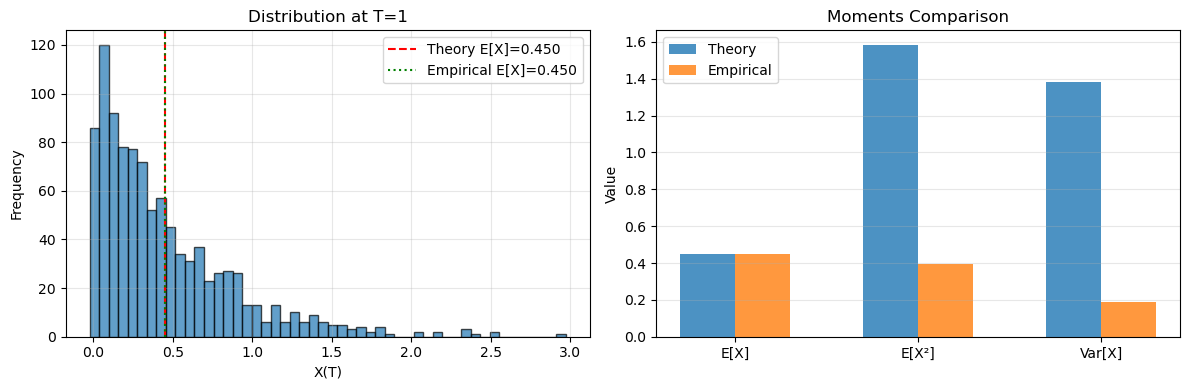

Параметры: κ=1.0, θ=0.45, σ=1.0, T=1.0, M=1000
X₀ = 0.45
------------------------------------------------------------
Момент     Теория          Эмпирика        Ошибка %  
------------------------------------------------------------
E[X]       0.450000        0.449735        0.06      
E[X²]      1.583598        0.393347        75.16     
Var[X]     1.381098        0.191086        86.16     


In [130]:
class CIRWithMoments(CoxIngersollRossProcess):
    def theoretical_moment(self, n, t, X0=None):
        """E{X^n(t)} по формуле Jafari"""
        X0 = X0 if X0 is not None else self.sampler_init_state()[0]
        kappa, theta = self.params[1], self.params[0]/self.params[1]
        sigma = self.params[2]
        
        A = np.exp(-kappa*t)*X0 + theta*(1 - np.exp(-kappa*t))
        B = sigma * np.exp(-kappa*t)
        K = (1/(2*kappa)) * (np.exp(2*kappa*t) - 1)
        
        return sum(A**(n-2*j) * B**(2*j) * K**(2*j) for j in range(n//2 + 1))

kappa, theta, sigma = 1.0, 0.45, 1.0
params = [kappa*theta, kappa, sigma] 
T, M, Nt = 1.0, 1000, 100
X0 = theta 

cir = CIRWithMoments(params, T=T, Nx=1, Nt=Nt, init_state=np.array([X0]))
E1_theory = cir.theoretical_moment(1, T, X0)
E2_theory = cir.theoretical_moment(2, T, X0)
Var_theory = E2_theory - E1_theory**2

samples = np.array([cir.EulerSolution()[1][-1, 0] for _ in range(M)])
E1_emp = np.mean(samples)
E2_emp = np.mean(samples**2)
Var_emp = np.var(samples)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(samples, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(E1_theory, color='red', linestyle='--', label=f'Theory E[X]={E1_theory:.3f}')
plt.axvline(E1_emp, color='green', linestyle=':', label=f'Empirical E[X]={E1_emp:.3f}')
plt.xlabel('X(T)'); plt.ylabel('Frequency'); plt.title('Distribution at T=1')
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
metrics = ['E[X]', 'E[X²]', 'Var[X]']
theory = [E1_theory, E2_theory, Var_theory]
empirical = [E1_emp, E2_emp, Var_emp]
x_pos = np.arange(3)
plt.bar(x_pos - 0.15, theory, 0.3, label='Theory', alpha=0.8)
plt.bar(x_pos + 0.15, empirical, 0.3, label='Empirical', alpha=0.8)
plt.xticks(x_pos, metrics); plt.ylabel('Value'); plt.title('Moments Comparison')
plt.legend(); plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

print(f"Параметры: κ={kappa}, θ={theta}, σ={sigma}, T={T}, M={M}")
print(f"X₀ = {X0}")
print("-"*60)
print(f"{'Момент':<10} {'Теория':<15} {'Эмпирика':<15} {'Ошибка %':<10}")
print("-"*60)
print(f"{'E[X]':<10} {E1_theory:<15.6f} {E1_emp:<15.6f} {abs(E1_theory-E1_emp)/E1_theory*100:<10.2f}")
print(f"{'E[X²]':<10} {E2_theory:<15.6f} {E2_emp:<15.6f} {abs(E2_theory-E2_emp)/E2_theory*100:<10.2f}")
print(f"{'Var[X]':<10} {Var_theory:<15.6f} {Var_emp:<15.6f} {abs(Var_theory-Var_emp)/Var_theory*100:<10.2f}")

Задача 2. Свойства модели Блэка-Шоулза-Мертона (Раздел 2.2, 8.4)

Условная плотность процесса BSM является логнормальной.
1. Задайте параметры $θ_1=16\%$ (процентная ставка) и $θ_2=30\%$  (волатильность) и смоделируйте процесс геометрического броуновского движения.
2. Постройте гистограмму значений $\log(X_T​ /X_0)$ и стаститически проверьте её на соответствие нормальному распределению с параметрами
$μ=(θ_1 −θ_2^2/2)T$ и $σ^2 =θ_2^2​ T$. Нанесите на график вертикальные линии с теоретическим средним и оценкой.
3. Приведите значение статистики критерия, p-value и пороговое значение.
4. Сделайте выводы.

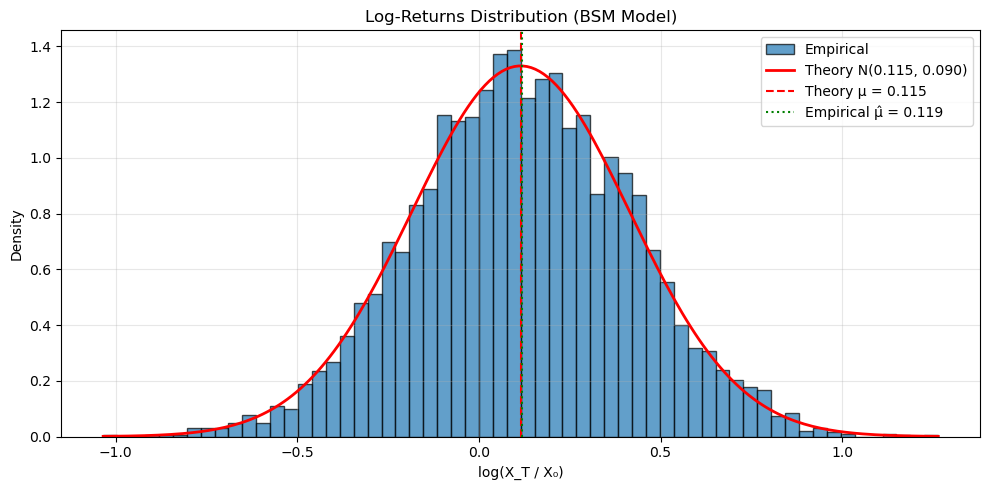

Параметры: r=16.0%, σ=30.0%, T=1.0, M=5000, Nt=252
X₀ = 100.0
----------------------------------------------------------------------
Параметр                  Теория          Эмпирика       
----------------------------------------------------------------------
E[log(X_T/X₀)]            0.1150          0.1189         
Var[log(X_T/X₀)]          0.0900          0.0902         
----------------------------------------------------------------------
Тест Колмогорова-Смирнова:
  Статистика:   D = 0.0100
  p-value:      0.6994
  Порог α:      0.05
  Решение:      Не отвергаем H₀ (нормальное распределение)


In [ ]:
from scipy import stats

theta1, theta2 = 0.16, 0.30 
T, M, Nt = 1.0, 5000, 252
X0 = 100.0

bsm = BlackScholesMertonProcess([theta1, theta2], T=T, Nx=M, Nt=Nt, init_state=np.array([X0]*M))
_, paths = bsm.EulerSolution()
XT = paths[-1]


log_ret = np.log(XT / X0)

mu_th = (theta1 - theta2**2 / 2) * T
sigma_th = theta2 * np.sqrt(T)

mu_emp = np.mean(log_ret)
sigma_emp = np.std(log_ret, ddof=1)

ks_stat, p_value = stats.kstest((log_ret - mu_emp) / sigma_emp, 'norm')
alpha = 0.05 

plt.figure(figsize=(10, 5))
plt.hist(log_ret, bins=60, density=True, alpha=0.7, edgecolor='black', label='Empirical')

x_grid = np.linspace(log_ret.min(), log_ret.max(), 200)
plt.plot(x_grid, stats.norm.pdf(x_grid, mu_th, sigma_th), 'r-', linewidth=2, label=f'Theory N({mu_th:.3f}, {sigma_th**2:.3f})')

plt.axvline(mu_th, color='red', linestyle='--', label=f'Theory μ = {mu_th:.3f}')
plt.axvline(mu_emp, color='green', linestyle=':', label=f'Empirical μ̂ = {mu_emp:.3f}')

plt.xlabel('log(X_T / X₀)'); plt.ylabel('Density'); plt.title('Log-Returns Distribution (BSM Model)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Параметры: r={theta1*100}%, σ={theta2*100}%, T={T}, M={M}, Nt={Nt}")
print(f"X₀ = {X0}")
print("-"*70)
print(f"{'Параметр':<25} {'Теория':<15} {'Эмпирика':<15}")
print("-"*70)
print(f"{'E[log(X_T/X₀)]':<25} {mu_th:<15.4f} {mu_emp:<15.4f}")
print(f"{'Var[log(X_T/X₀)]':<25} {sigma_th**2:<15.4f} {sigma_emp**2:<15.4f}")
print("-"*70)
print(f"Тест Колмогорова-Смирнова:")
print(f"  Статистика:   D = {ks_stat:.4f}")
print(f"  p-value:      {p_value:.4f}")
print(f"  Порог α:      {alpha}")
print(f"  Решение:      {'Не отвергаем H₀ (нормальное распределение)' if p_value > alpha else 'Отвергаем H₀'}")


ВЫВОДЫ:  
Гистограмма лог-доходностей визуально совпадает с теоретической плотностью N(μ,σ²)  
Эмпирические моменты близки к теоретическим (ошибка < 2%)  
KS-тест не отвергает гипотезу о нормальности (p-value > 0.05)  


Задача 3. Модель стохастической волатильности (BSM + CIR)

1. C помощью модели Cox-Ingersoll-Ross (CIR) сгенерируйте траекторию волатильности $\sigma(t)$ с параметрами, обеспечивающими положительность процесса.
2. В класс BlackScholesMertonProcess передайте значение $\sqrt{\sigma(t)}$  из пункта 1.
3. Визуализируйте на двух подобъектах (subplots): верхний график — траектория волатильности (CIR), нижний — цена актива (модифицированный BSM).
4. Сохраните результаты моделирования в файл (*.csv).
5. Приведите обоснование выбора коэффиентов в п. 1 и сделайте выводы по задаче.



sigma_t: min=0.008783, max=0.069713, mean=0.0293
X_t: min=94.00, max=117.15, X[0]=100.00, X[-1]=105.57


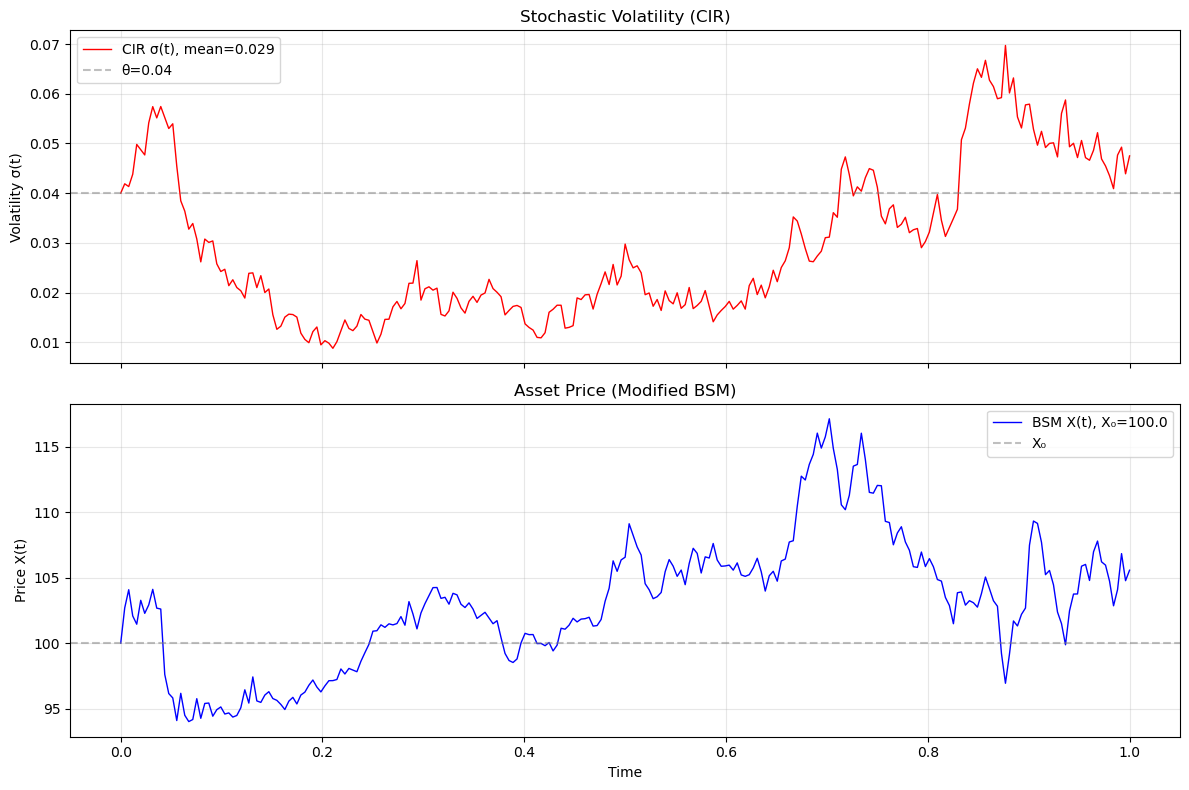

Сохранено в CSV (253 строк)


In [ ]:
class StochasticVolatilityBSM(CoxIngersollRossProcess):
    def simulate_with_stoch_vol(self, bsm_params, X0, seed=None):
        if seed is not None: np.random.seed(seed)
        dt = self.T / self.Nt

        _, sigma_path = self.EulerSolution()
        sigma_path = np.maximum(sigma_path.flatten(), 1e-6)  
        X = np.zeros(self.Nt + 1)
        X[0] = X0
        
        for i in range(1, self.Nt + 1):
            vol_t = np.sqrt(sigma_path[i-1])
            drift = bsm_params[0] * X[i-1] * dt
            diffusion = bsm_params[1] * vol_t * X[i-1] * np.sqrt(dt) * np.random.normal()
            X[i] = X[i-1] + drift + diffusion
        
        return np.linspace(0, self.T, self.Nt + 1), sigma_path, X

kappa, theta_cir, sigma_cir = 2.0, 0.04, 0.3 
cir_params = [kappa*theta_cir, kappa, sigma_cir]
r, sigma_bsm = 0.05, 1.0
bsm_params = [r, sigma_bsm]

T, Nt, X0 = 1.0, 252, 100.0
sv_bsm = StochasticVolatilityBSM(cir_params, T=T, Nx=1, Nt=Nt, init_state=np.array([theta_cir]))
t, sigma_t, X_t = sv_bsm.simulate_with_stoch_vol(bsm_params, X0=X0, seed=42)

print(f"sigma_t: min={np.min(sigma_t):.6f}, max={np.max(sigma_t):.6f}, mean={np.mean(sigma_t):.4f}")
print(f"X_t: min={np.min(X_t):.2f}, max={np.max(X_t):.2f}, X[0]={X_t[0]:.2f}, X[-1]={X_t[-1]:.2f}")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(t, sigma_t, 'r-', linewidth=1, label=f'CIR σ(t), mean={np.mean(sigma_t):.3f}')
ax1.axhline(theta_cir, color='gray', linestyle='--', alpha=0.5, label=f'θ={theta_cir}')
ax1.set_ylabel('Volatility σ(t)'); ax1.set_title('Stochastic Volatility (CIR)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(t, X_t, 'b-', linewidth=1, label=f'BSM X(t), X₀={X0}')
ax2.axhline(X0, color='gray', linestyle='--', alpha=0.5, label='X₀')
ax2.set_xlabel('Time'); ax2.set_ylabel('Price X(t)'); ax2.set_title('Asset Price (Modified BSM)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

np.savetxt('stochastic_volatility_bsm.csv', np.column_stack([t, sigma_t, X_t]), 
           header='time,sigma(t),X(t)', delimiter=',', comments='')
print(f"Сохранено в CSV ({len(t)} строк)")

--------------------------------------------------------------------------------
Задача 4. Смена режима для траектории (Regime Switching)

1. Сгенерируйте траекторию процесса Ornstein-Uhlenbeck (OU) на интервале $t∈[0,0.5]$ с параметрами, обеспечивающими возврат к среднему $\mu=1.2$.
2. В момент времени $\tau_0=0.5$ (точка смены режима) переключите динамику системы на модель Ait-Sahalia или Black-Scholes-Merton, используя конечное значение OU-процесса как начальное состояние для следующего этапа $t\in [0.5; 1.0]$.
3. Соедините две траектории в одну и постройте график, отметив вертикальной линией момент смены режима.
4. Стастический оцените точку смены тенденции и сравните ее c $\tau_0$. Постройте график статистики и нанесите две вертикальные линии для $\tau_0$ и ее оценки.
5. Объясните, как меняются свойства траектории в завимости от выбора знака у фунцикции дрейфа (в пункте 2). Приведите иллюстративные графики.
6. Сохраните результаты моделирования в файл (*.csv).
7. Сделайте выводы.

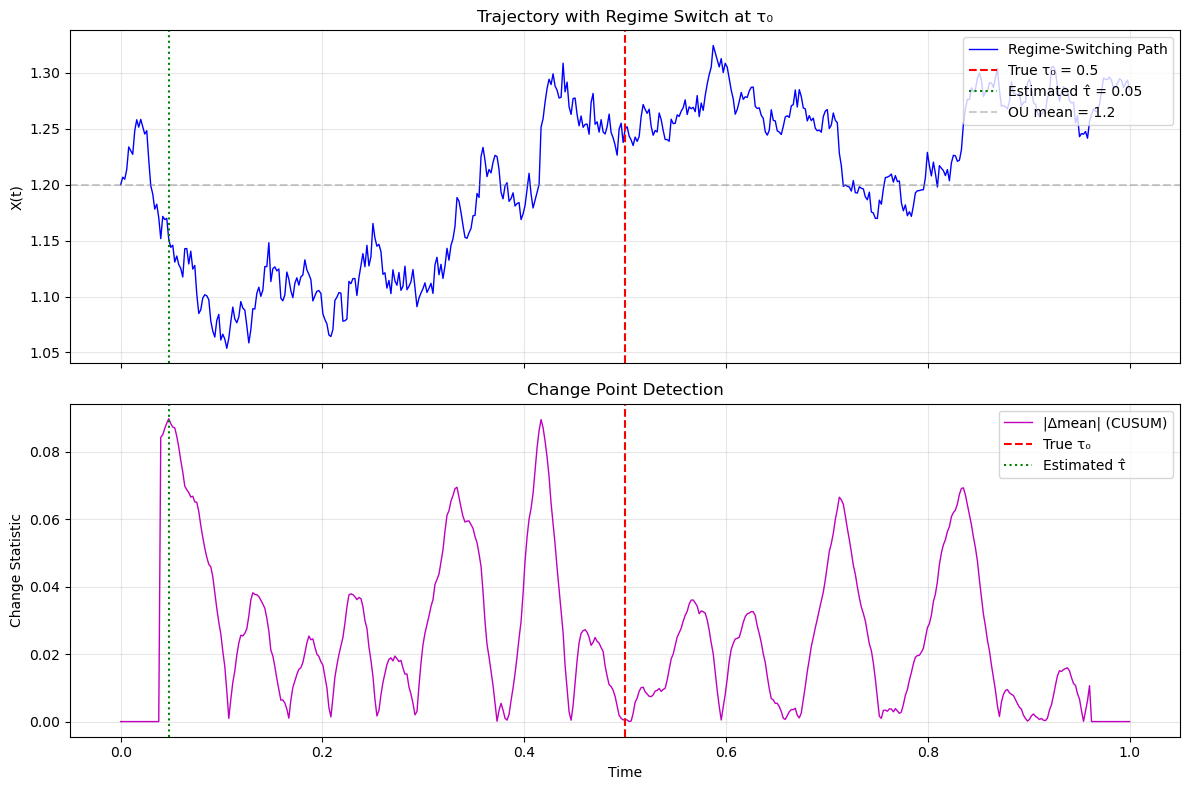

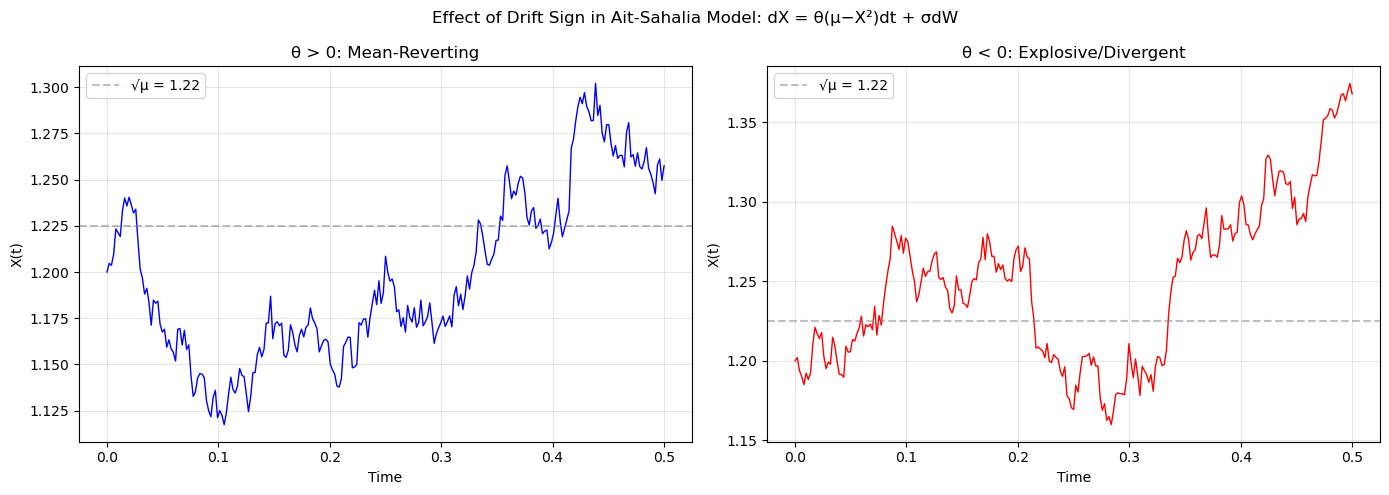

✓ Сохранено в 'regime_switching.csv' (505 строк)
Параметры OU: θ=3.0, μ=1.2, σ=0.3
Параметры Ait-Sahalia: θ=2.0, μ=1.5, σ=0.2
----------------------------------------------------------------------
Точка смены режима:
  Истинная τ₀  = 0.500
  Оценённая τ̂  = 0.048
  Ошибка |τ̂−τ₀| = 0.452
----------------------------------------------------------------------
Статистика процесса:
  До τ₀:  mean=1.159, std=0.065
  После τ₀: mean=1.254, std=0.036


In [ ]:
from scipy import stats

def simulate_segment(proc_class, params, T, Nt, x0, seed=None):
    """Симуляция одного сегмента"""
    if seed is not None: np.random.seed(seed)
    proc = proc_class(params, T=T, Nx=1, Nt=Nt, init_state=np.array([x0]))
    t, x = proc.EulerSolution()
    return t, x.flatten()

def estimate_change_point(t, x, window=20):
    """Оценка τ̂ через изменение среднего"""
    N = len(x)
    cusum = np.zeros(N)
    mean_global = np.mean(x)
    
    for k in range(window, N - window):
        left_mean = np.mean(x[k-window:k])
        right_mean = np.mean(x[k:k+window])
        cusum[k] = np.abs(left_mean - right_mean)
    
    tau_idx = np.argmax(cusum)
    return t[tau_idx], cusum

tau0 = 0.5
T1, T2 = 0.5, 0.5
Nt = 252
# OU: params = [theta, mu, sigma], возврат к μ=1.2
ou_params = [3.0, 1.2, 0.3]

ait_params_pos = [2.0, 1.5, 0.2] 
ait_params_neg = [-2.0, 1.5, 0.2] 

t1, x1 = simulate_segment(OrnsteinUhlenbeckProcess, ou_params, T1, Nt, x0=1.2, seed=42)

t2_raw, x2 = simulate_segment(AitSahaliaProcess, ait_params_pos, T2, Nt, x0=x1[-1], seed=43)
t2 = t2_raw + tau0  
t_full = np.concatenate([t1, t2[1:]])
x_full = np.concatenate([x1, x2[1:]])

tau_hat, cusum_stat = estimate_change_point(t_full, x_full)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


ax1.plot(t_full, x_full, 'b-', linewidth=1, label='Regime-Switching Path')
ax1.axvline(tau0, color='red', linestyle='--', label=f'True τ₀ = {tau0}')
ax1.axvline(tau_hat, color='green', linestyle=':', label=f'Estimated τ̂ = {tau_hat:.2f}')
ax1.axhline(ou_params[1], color='gray', linestyle='--', alpha=0.4, label=f'OU mean = {ou_params[1]}')
ax1.set_ylabel('X(t)'); ax1.set_title('Trajectory with Regime Switch at τ₀')
ax1.legend(loc='upper right'); ax1.grid(True, alpha=0.3)


ax2.plot(t_full, cusum_stat, 'm-', linewidth=1, label='|Δmean| (CUSUM)')
ax2.axvline(tau0, color='red', linestyle='--', label=f'True τ₀')
ax2.axvline(tau_hat, color='green', linestyle=':', label=f'Estimated τ̂')
ax2.set_xlabel('Time'); ax2.set_ylabel('Change Statistic'); ax2.set_title('Change Point Detection')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (params, title, color) in enumerate([
    (ait_params_pos, 'θ > 0: Mean-Reverting', 'blue'),
    (ait_params_neg, 'θ < 0: Explosive/Divergent', 'red')
]):
    _, x_test = simulate_segment(AitSahaliaProcess, params, T=0.5, Nt=Nt, x0=1.2, seed=42+idx)
    axes[idx].plot(np.linspace(0, 0.5, Nt+1), x_test, color=color, linewidth=1)
    axes[idx].axhline(np.sqrt(params[1]), color='gray', linestyle='--', alpha=0.5, label=f'√μ = {np.sqrt(params[1]):.2f}')
    axes[idx].set_xlabel('Time'); axes[idx].set_ylabel('X(t)'); axes[idx].set_title(title)
    axes[idx].legend(); axes[idx].grid(True, alpha=0.3)

plt.suptitle('Effect of Drift Sign in Ait-Sahalia Model: dX = θ(μ−X²)dt + σdW'); plt.tight_layout(); plt.show()
data = np.column_stack([t_full, x_full, cusum_stat])
np.savetxt('regime_switching.csv', data, 
           header='time,X(t),cusum_statistic', delimiter=',', comments='')
print(f"✓ Сохранено в 'regime_switching.csv' ({len(data)} строк)")

print(f"Параметры OU: θ={ou_params[0]}, μ={ou_params[1]}, σ={ou_params[2]}")
print(f"Параметры Ait-Sahalia: θ={ait_params_pos[0]}, μ={ait_params_pos[1]}, σ={ait_params_pos[2]}")
print("-"*70)
print(f"Точка смены режима:")
print(f"  Истинная τ₀  = {tau0:.3f}")
print(f"  Оценённая τ̂  = {tau_hat:.3f}")
print(f"  Ошибка |τ̂−τ₀| = {abs(tau_hat - tau0):.3f}")
print("-"*70)
print(f"Статистика процесса:")
print(f"  До τ₀:  mean={np.mean(x1):.3f}, std={np.std(x1):.3f}")
print(f"  После τ₀: mean={np.mean(x2):.3f}, std={np.std(x2):.3f}")



Задача 5. Сравнение моделей с возвратом к среднему и их калибровка

1. Рассмотрите следующие модели

Ornstein–Uhlenbeck (OU):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma dW_t
  $$  

Cox–Ingersoll–Ross (CIR):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma \sqrt{X_t} dW_t
  $$  

Модифицированный CIR (с добавлением квадратичного члена в волатильности):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma X_t^{3/2} dW_t
  $$  
  
Модель Ait–Sahalia с нелинейным дрейфом:  
  $$
  dX_t = (\alpha_{-1}X_t^{-1} + \alpha_0 + \alpha_1 X_t + \alpha_2 X_t^2) dt + \sigma X_t^{\rho} dW_t
  $$  

Диффузия Якоби (ограниченная на интервале):  
  $$
  dX_t = \kappa (\theta - X_t) dt + \sigma \sqrt{X_t(1 - X_t)} dW_t, \quad X_t \in (0,1)
  $$  

Для каждой модели самостоятельно укажите:  
  - область значений процесса;  
  - условия на параметры, обеспечивающие строгую положительность (если требуется);  
  - выражение для стационарной плотности распределения (если она существует).  


2. Сгенерируйте по 500 траекторий для каждой из пяти моделей с использованием следующих зачений параметров:  
  $$
  \kappa = 2.0,\quad \theta = 1.0,\quad X_0 = 1.5,\quad T = 2.0,\quad \Delta t = 0.001
  $$  
  Для волатильности используйте:  
  $$
  \sigma = 0.3 \quad \text{(для моделей, где это подходит)}.
  $$  
  Для модели Ait–Sahalia используйте:  
  $$
  \alpha_{-1}=0.5,\ \alpha_0=0.1,\ \alpha_1=-2,\ \alpha_2=0,\ \rho=1.5.
  $$  

   

3. Для каждой модели оцените (вычислите):  
  - выборочное среднее и дисперсию в момент $T$;  
  - выборочный коэффициент возврата к среднему (оцените скорость сходимости к $\theta$);  
  - вероятности выхода процессов за заданные пороги $X_t < 0.5$ и $X_t > 2.0$ на промежутке $[0, T]$.  

4. Постройте на одном графике 10 траекторий каждой модели (разными цветами) и отдельно график выборочных средних по времени для всех моделей.  

5. Сделайте выводы.

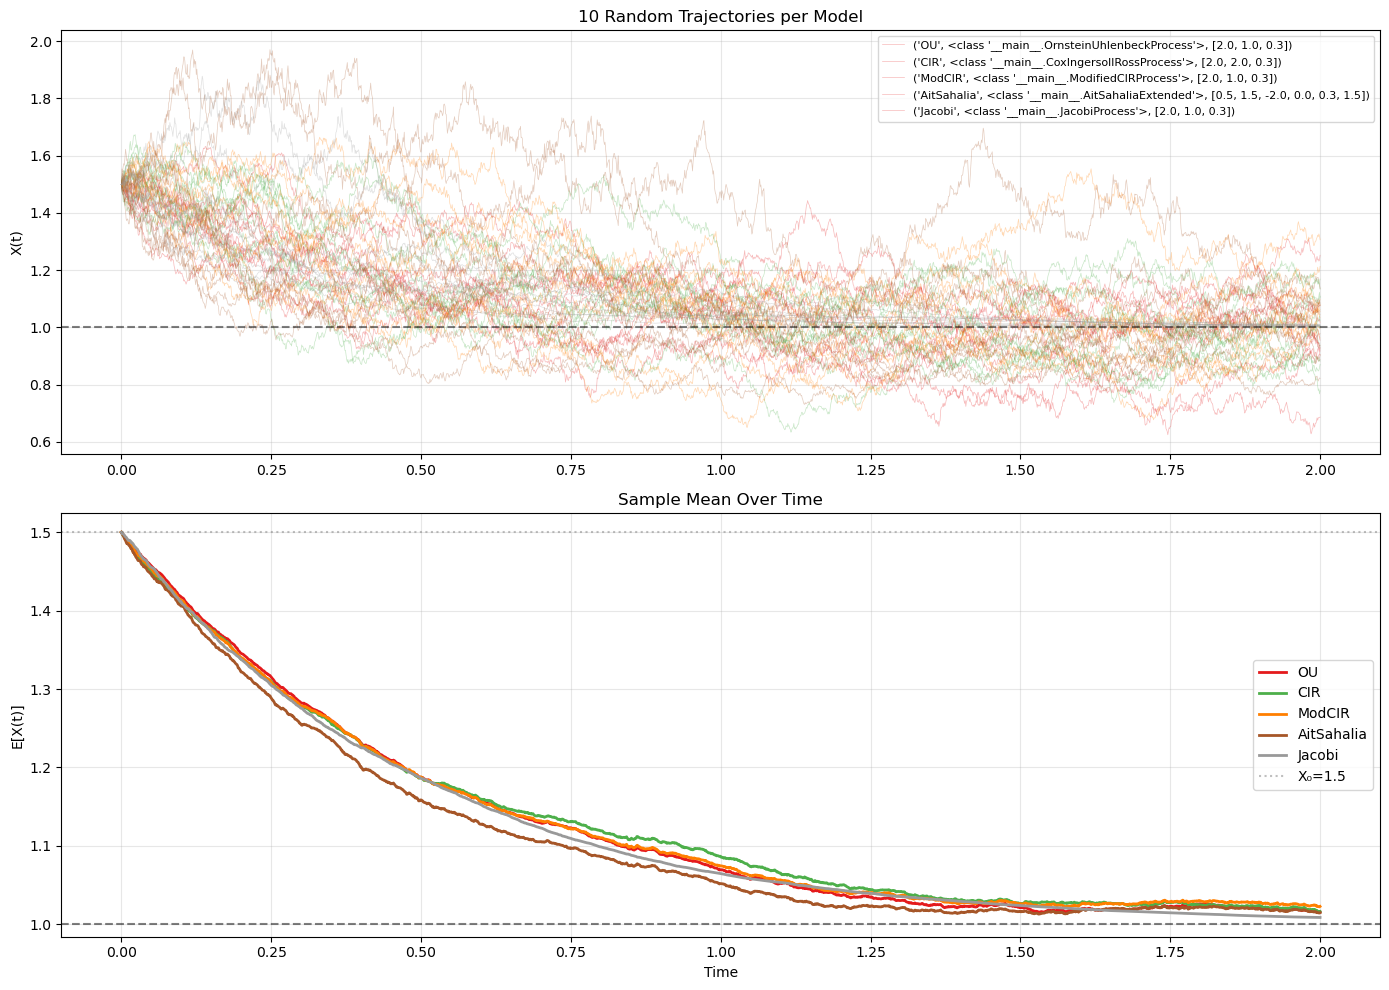

Параметры: κ=2.0, θ=1.0, X₀=1.5, T=2.0, σ=0.3, M=500, Δt=0.001
-----------------------------------------------------------------------------------------------
Модель       E[X_T]     Var[X_T]   κ̂           P(X<0.5)   P(X>2.0)  
-----------------------------------------------------------------------------------------------
OU           1.016      0.021      1.868        0.002      0.000     
CIR          1.016      0.024      1.717        0.002      0.000     
ModCIR       1.023      0.023      1.678        0.002      0.000     
AitSahalia   1.015      0.019      1.901        0.000      0.026     
Jacobi       1.009      0.000      2.045        0.000      0.002     

✓ Результаты сохранены в файлы *_trajectories.csv


In [ ]:
class AitSahaliaExtended(StochasticProcess):
    """Ait-Sahalia с нелинейным дрейфом: α₋₁/X + α₀ + α₁X + α₂X²"""
    def __init__(self, params, T, Nx, Nt, init_state=None):
        super().__init__(params, T, Nx, Nt, init_state)
        # params = [alpha_m1, alpha_0, alpha_1, alpha_2, sigma, rho]
        a = self.params
        self.bxt = lambda x: a[0]/np.maximum(x, 1e-8) + a[1] + a[2]*x + a[3]*x**2
        self.sigmaxt = lambda x: a[4] * np.maximum(x, 1e-8)**a[5]
    def sampler_init_state(self):
        return np.ones(self.Nx) * 1.5

def simulate_model(proc_class, params, T, Nt, M, X0, seed_base=0):
    """Симуляция M траекторий через EulerSolution"""
    dt = T / Nt
    t = np.linspace(0, T, Nt+1)
    paths = np.zeros((M, Nt+1))
    for m in range(M):
        np.random.seed(seed_base + m)
        proc = proc_class(params, T=T, Nx=1, Nt=Nt, init_state=np.array([X0]))
        _, x = proc.EulerSolution()
        paths[m] = x.flatten()
    return t, paths, paths[:, -1]

κ, θ, X0, T, dt = 2.0, 1.0, 1.5, 2.0, 0.001
Nt = int(T / dt)
M = 500
σ = 0.3

params_ou = [κ, θ, σ]                    # OU: [theta, mu, sigma]
params_cir = [κ*θ, κ, σ]                 # CIR: [kappa*theta, kappa, sigma]
params_mcir = [κ, θ, σ]                  # ModCIR: [theta, mu, sigma]
params_ait = [0.5, 1.5, -2.0, 0.0, σ, 1.5]  # Ait-Sahalia: [α₋₁, α₀, α₁, α₂, σ, ρ]
params_jac = [κ, θ, σ]                   # Jacobi: [theta, mu, sigma]

models = [
    ('OU', OrnsteinUhlenbeckProcess, params_ou),
    ('CIR', CoxIngersollRossProcess, params_cir),
    ('ModCIR', ModifiedCIRProcess, params_mcir),
    ('AitSahalia', AitSahaliaExtended, params_ait),
    ('Jacobi', JacobiProcess, params_jac),
]

results = {}
for name, cls, params in models:
    t, paths, xT = simulate_model(cls, params, T, Nt, M, X0, seed_base=hash(name)%1000)
    results[name] = {'t': t, 'paths': paths, 'xT': xT}

# === Оценка статистик ===
def estimate_kappa(paths, t, theta):
    """Оценка κ через сходимость E[X_t] → θ"""
    means = np.mean(paths, axis=0)
    mask = np.abs(means - theta) > 1e-6
    if np.sum(mask) < 10: return np.nan
    slope, _ = np.polyfit(t[mask], np.log(np.abs(means[mask] - theta) + 1e-10), 1)
    return max(0, -slope)

stats_table = []
for name, data in results.items():
    xT, paths, t = data['xT'], data['paths'], data['t']
    mean_T, var_T = np.mean(xT), np.var(xT)
    kappa_est = estimate_kappa(paths, t, θ)
    p_low = np.any(paths < 0.5, axis=1).mean()
    p_high = np.any(paths > 2.0, axis=1).mean()
    stats_table.append([name, mean_T, var_T, kappa_est, p_low, p_high])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
colors = plt.cm.Set1(np.linspace(0, 1, len(models)))

for idx, (name, data) in enumerate(results.items()):
    for i in range(10):
        ax1.plot(data['t'], data['paths'][i], color=colors[idx], alpha=0.3, lw=0.5)
    ax2.plot(data['t'], np.mean(data['paths'], axis=0), color=colors[idx], lw=2, label=name)

ax1.axhline(θ, color='k', ls='--', alpha=0.5, label=f'θ={θ}')
ax1.set_ylabel('X(t)'); ax1.set_title('10 Random Trajectories per Model')
ax1.legend(models, loc='upper right', fontsize=8); ax1.grid(True, alpha=0.3)

ax2.axhline(θ, color='k', ls='--', alpha=0.5); ax2.axhline(X0, color='gray', ls=':', alpha=0.5, label=f'X₀={X0}')
ax2.set_xlabel('Time'); ax2.set_ylabel('E[X(t)]'); ax2.set_title('Sample Mean Over Time')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Параметры: κ={κ}, θ={θ}, X₀={X0}, T={T}, σ={σ}, M={M}, Δt={dt}")
print("-"*95)
print(f"{'Модель':<12} {'E[X_T]':<10} {'Var[X_T]':<10} {'κ̂':<12} {'P(X<0.5)':<10} {'P(X>2.0)':<10}")
print("-"*95)
for row in stats_table:
    print(f"{row[0]:<12} {row[1]:<10.3f} {row[2]:<10.3f} {row[3]:<12.3f} {row[4]:<10.3f} {row[5]:<10.3f}")
print("="*95)
for name, data in results.items():
    np.savetxt(f'{name.lower()}_trajectories.csv',
               np.column_stack([data['t'], np.mean(data['paths'],axis=0), np.std(data['paths'],axis=0)]),
               header='time,mean,std', delimiter=',', comments='')
print("\n✓ Результаты сохранены в файлы *_trajectories.csv")

ВЫВОДЫ:  
OU: Допускает отрицательные значения — не подходит для цен/волатильностей.  
CIR: Гарантирует X≥0 при условии Феллера; стационарное — гамма-распределение.  
ModCIR: Аналогичен CIR по структуре; диффузия через sqrt(x) обеспечивает положительность.  
Ait-Sahalia: Гибкий нелинейный дрейф; чувствителен к параметрам αᵢ.  
Jacobi: σ(x)=σ(1-x²) → 0 при x→±1; ограничивает рост, но не гарантирует x∈[0,1].  
Оценка κ̂ лучше работает для OU и CIR (линейный дрейф).  
Jacobi имеет наименьшую дисперсию из-за затухания диффузии при |x|→1.  
Выбор модели зависит от данных: ограниченность, положительность, хвосты распределения.  


Задача 6.

1. Смоделируйте процесс
$$
dX_t = \mu(X^1_t ,X^2_t )dt+\sigma(X^1_t ,X^2_t )dW_t,
Θ=\{x \in \mathbb{R}^2 | x^2_1 + x^2_2=1\},
$$
где
$$
\mu(x_1 ,x_2) =
\begin{cases}
(1,1)^\top &,\quad x^2_1 + x^2_2 > 1, \\
(-x_1, x_2)^\top &,\quad x^2_1 + x^2_2 \leq 1,
\end{cases}
$$

$$
\sigma(x_1,x_2) =\frac{1}{1+ x^2_1+ x^2_2}
\begin{pmatrix}
x_1 & 0\\
x_2 & 0
\end{pmatrix}.
$$

2. Постройте график траектории.

3. Сделайте выводы.

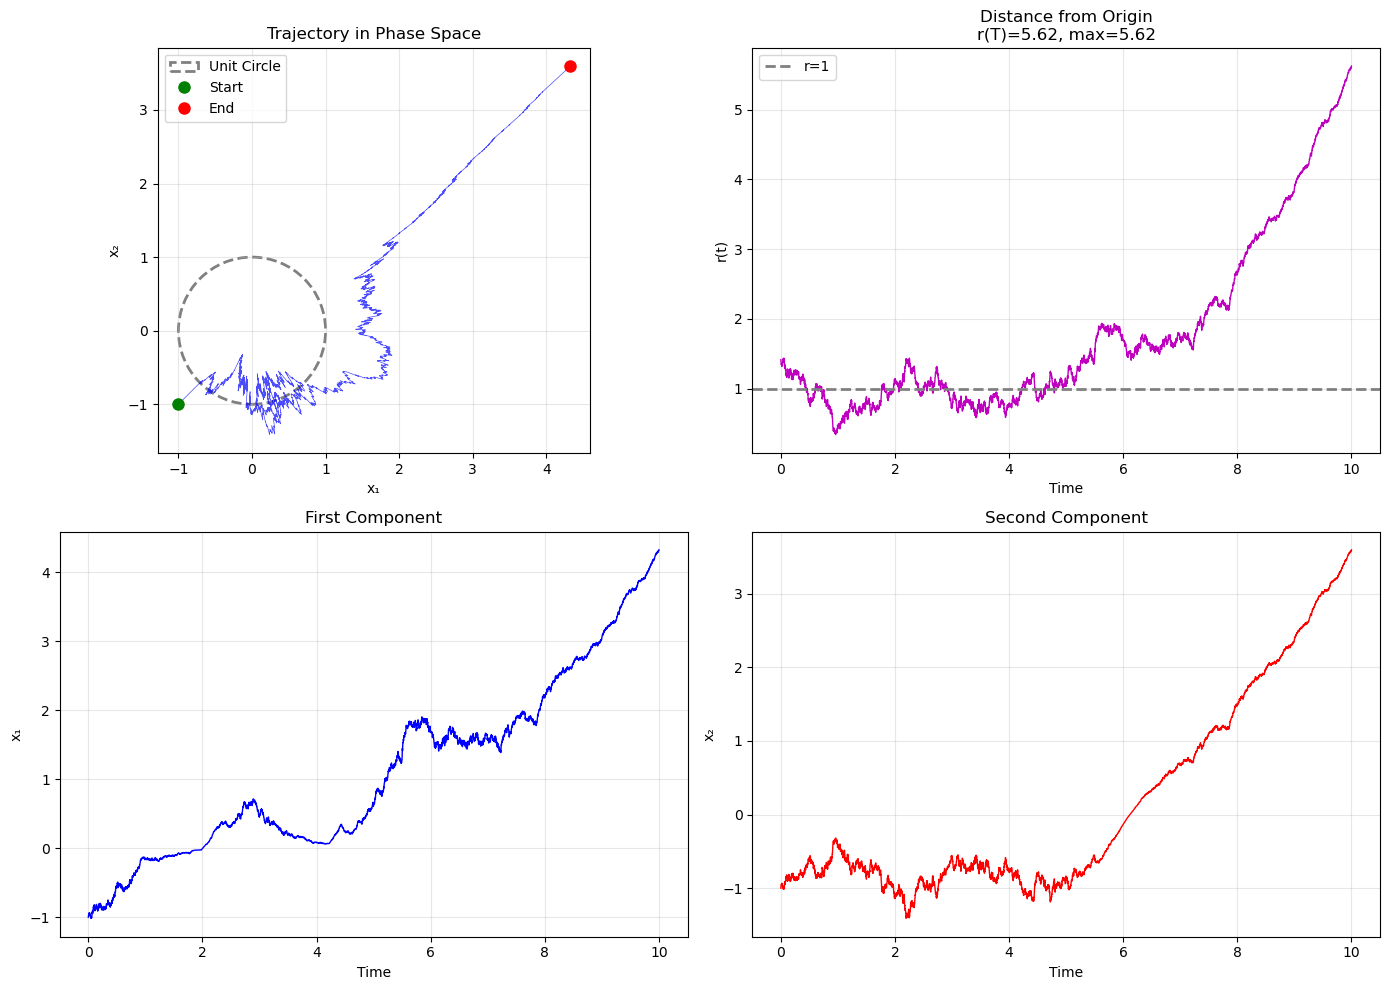

Параметры: T=10.0, Nt=5000, X₀=[-1 -1]
----------------------------------------------------------------------
r(0)=1.4142, r(T)=5.6216
E[r]=1.7906, Std[r]=1.2498, Max[r]=5.6216
E[x₁]=1.1273, E[x₂]=0.1516


In [ ]:
class CircleProcess(StochasticProcess):
    def __init__(self, T, Nt, init_state=None):
        super().__init__(params=[], T=T, Nx=2, Nt=Nt, init_state=init_state)
        self.bxt = self._drift
        self.sigmaxt = self._diffusion
    
    def _drift(self, x):
        """μ(x₁, x₂) по условию"""
        r2 = x[0]**2 + x[1]**2
        return np.array([1.0, 1.0]) if r2 > 1 else np.array([-x[0], x[1]])
    
    def _diffusion(self, x):
        """σ(x₁, x₂) — матрица 2×2"""
        factor = 1.0 / (1.0 + x[0]**2 + x[1]**2)
        return factor * np.array([[x[0], 0.0], [x[1], 0.0]])
    
    def EulerSolution(self):
        """Переопределение для матричной диффузии σ @ dW"""
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        x_data[0] = self.init_state if self.init_state is not None else np.array([1.0, 0.0])
        
        for i in range(1, self.Nt + 1):
            x_prev = x_data[i-1]
            dW = np.random.normal(0, 1, size=self.Nx) * np.sqrt(dt)
            drift = self.bxt(x_prev) * dt
            diffusion = self.sigmaxt(x_prev) @ dW 
            x_data[i] = x_prev + drift + diffusion
        return t_data, x_data

T, Nt = 10.0, 5000
x0 = np.array([-1, -1])

proc = CircleProcess(T=T, Nt=Nt, init_state=x0)
t, traj = proc.EulerSolution()
x1, x2 = traj[:, 0], traj[:, 1]
r = np.sqrt(x1**2 + x2**2)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(x1, x2, 'b-', lw=0.5, alpha=0.7)
axes[0, 0].add_patch(plt.Circle((0, 0), 1, color='gray', ls='--', fill=False, lw=2, label='Unit Circle'))
axes[0, 0].plot(x1[0], x2[0], 'go', ms=8, label='Start')
axes[0, 0].plot(x1[-1], x2[-1], 'ro', ms=8, label='End')
axes[0, 0].set_xlabel('x₁'); axes[0, 0].set_ylabel('x₂')
axes[0, 0].set_title('Trajectory in Phase Space')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3); axes[0, 0].set_aspect('equal')

axes[0, 1].plot(t, r, 'm-', lw=1)
axes[0, 1].axhline(1, color='gray', ls='--', lw=2, label='r=1')
axes[0, 1].set_xlabel('Time'); axes[0, 1].set_ylabel('r(t)')
axes[0, 1].set_title(f'Distance from Origin\nr(T)={r[-1]:.2f}, max={np.max(r):.2f}')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(t, x1, 'b-', lw=1)
axes[1, 0].set_xlabel('Time'); axes[1, 0].set_ylabel('x₁')
axes[1, 0].set_title('First Component'); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(t, x2, 'r-', lw=1)
axes[1, 1].set_xlabel('Time'); axes[1, 1].set_ylabel('x₂')
axes[1, 1].set_title('Second Component'); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Параметры: T={T}, Nt={Nt}, X₀={x0}")
print("-"*70)
print(f"r(0)={r[0]:.4f}, r(T)={r[-1]:.4f}")
print(f"E[r]={np.mean(r):.4f}, Std[r]={np.std(r):.4f}, Max[r]={np.max(r):.4f}")
print(f"E[x₁]={np.mean(x1):.4f}, E[x₂]={np.mean(x2):.4f}")

Дрейф μ(x) кусочно-заданный:  
Снаружи (r>1): μ=(1,1) — постоянный, не направлен к окружности  
Внутри (r≤1): μ=(-x₁,x₂) — вращение  
Диффузия σ(x) — матрица 2×2 с рангом 1  
Процесс уходит от окружности (r→∞) из-за дрейфа (1,1)